In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [4]:
subgraph_llm = init_chat_model("google_genai:gemini-2.5-flash-lite")

In [5]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [6]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [7]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [8]:
parent_llm = init_chat_model("google_genai:gemini-2.5-flash-lite")

In [9]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [10]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [11]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

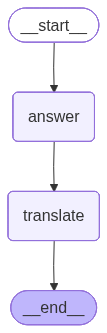

In [12]:
graph = parent_builder.compile()
graph

In [13]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics is the fundamental theory in physics that describes nature at the smallest scales of energy and matter. It deals with the behavior of particles like **electrons, photons (light particles), and atoms**, and how they interact with each other and with forces.\n\nHere\'s a breakdown of what makes quantum physics distinct and important:\n\n**Key Concepts that Differentiate Quantum Physics:**\n\n*   **Quantization:** Unlike classical physics, where quantities like energy can have any value, in quantum physics, these quantities are *quantized*. This means they can only exist in discrete, specific packets or "quanta." Think of it like stairs instead of a ramp – you can only be on a specific step, not in between.\n    *   **Example:** Electrons in an atom can only occupy specific energy levels. They can jump between these levels but can\'t exist at energies in between.\n\n*   **Wave-Particle Duality:** One of the most mind-